# Data Understanding: Eksplorasi Dataset Iris

Pada tahap ini, saya akan melakukan proses **Data Understanding** untuk mengenal lebih dalam dataset Iris. Proses ini sangat penting dalam siklus data mining agar kita memahami karakteristik, kualitas, dan pola awal yang ada pada data sebelum melangkah ke tahap pemrosesan yang lebih rumit.

## 1. Eksplorasi Data Menggunakan Orange
Kita akan memulai proses Data Understanding dengan tools visual **Orange Data Mining**. Orange membantu kita menganalisis data secara interaktif tanpa perlu menulis kode, namun tetap memberikan insight yang mendalam.

## 1. Eksplorasi Data Menggunakan Orange

Kita akan memulai proses Data Understanding dengan tools visual **Orange Data Mining**. Orange membantu kita menganalisis data secara interaktif tanpa perlu menulis kode, namun tetap memberikan insight yang mendalam.

### Alur Kerja (Workflow) Orange
Berikut adalah alur kerja (workflow) yang saya bangun di Orange. Alur ini menggambarkan bagaimana data mengalir dari sumber hingga proses visualisasi dan analisis statistik:

![Workflow Orange](../docs/flow_work.png)

*Gambar di atas menunjukkan hubungan antara widget File, Select Columns, Rank, Data Table, Column Statistics, Pivot Table, Scatter Plot, Correlations, dan Box Plot.*

### Pemilihan Atribut (Select Columns)
Sebelum memulai analisis, saya menggunakan widget **Select Columns** untuk menentukan variabel mana yang menjadi fitur dan mana yang menjadi target:

![Select Columns](../docs/select_columns.png)

### Analisis Data Table
Berdasarkan tampilan pada **Data Table**, dataset ini memiliki 150 baris data dan 5 kolom variabel:

![Data Table](../docs/data_table.png)

Seluruh data dalam dataset ini lengkap tanpa adanya nilai yang kosong, sehingga dapat langsung digunakan untuk proses analisis.

### Ranking Variabel
Pada bagian **Rank**, dilakukan pemeringkatan variabel berdasarkan seberapa penting variabel tersebut dalam membedakan jenis bunga iris:

![Ranking Variabel](../docs/rank.png)

Variabel `petal_length` dan `petal_width` memiliki nilai tertinggi, yang berarti kedua variabel ini paling berpengaruh dalam menentukan jenis bunga iris.

### Visualisasi Scatter Plot
Pada tahap visualisasi data menggunakan fitur **Scatter Plot** di Orange, ditampilkan perbandingan antar variabel. Dari grafik terlihat bahwa data Iris-setosa membentuk kelompok yang cukup terpisah:

![Scatter Plot Orange](../docs/scatter.png)

### Analisis Korelasi
Pada tahap analisis menggunakan fitur **Correlations** di Orange, dilakukan perhitungan hubungan antar variabel numerik menggunakan metode Pearson correlation:

![Korelasi Orange](../docs/correlation.png)

Berdasarkan hasil, `petal_length` dan `petal_width` memiliki korelasi sangat kuat (+0.963).

### Statistik Kolom dan Box Plot
Pada bagian **Column Statistics**, ditampilkan ringkasan statistik seperti Mean, Median, Mode, Min, Max, dan Missing values:

![Column Statistics](../docs/statistic.png)

Sedangkan **Box Plot** menunjukkan penyebaran data untuk variabel `sepal_length` berdasarkan tiap spesies:

![Box Plot Orange](../docs/box_plot.png)

### Pivot Table
Pada bagian **Pivot Table**, ditampilkan jumlah data untuk setiap jenis bunga. Terlihat bahwa dataset ini seimbang dengan masing-masing spesies berjumlah 50 data:

![Pivot Table Orange](../docs/pivot.png)

## 2. Eksplorasi Data Menggunakan Python
Setelah secara visual menggunakan Orange, kita akan memvalidasi data menggunakan library Pandas dan Seaborn di Python untuk mendapatkan statistik yang lebih presisi.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Memuat dataset
df = pd.read_csv('IRIS.csv')

# Menampilkan 10 data pertama
display(df.head(10))

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


### Deskripsi Kolom
Dataset Iris terdiri dari 150 baris dengan atribut berikut:
* **Sepal Length/Width**: Ukuran kelopak bunga.
* **Petal Length/Width**: Ukuran mahkota bunga.
* **Species**: Target klasifikasi (Setosa, Versicolor, Virginica).

In [2]:
# Menghitung statistik deskriptif
stats = df.describe().T
stats['median'] = df.select_dtypes(include=['number']).median()
stats['mode'] = df.select_dtypes(include=['number']).mode().iloc[0]

display(stats[['mean', 'median', 'mode', 'std', 'min', 'max']])

,mean,median,mode,std,min,max
sepal_length,5.843333,5.80,5.0,0.828066,4.3,7.9
sepal_width,3.054000,3.00,3.0,0.433594,2.0,4.4
petal_length,3.758667,4.35,1.5,1.764420,1.0,6.9
petal_width,1.198667,1.30,0.2,0.763161,0.1,2.5


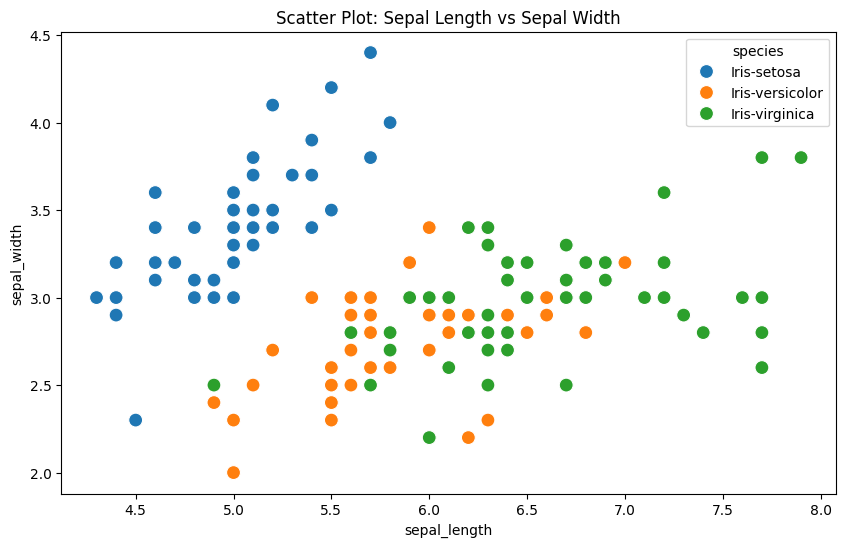

In [3]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='sepal_length', y='sepal_width', hue='species', s=100)
plt.title('Scatter Plot: Sepal Length vs Sepal Width')
plt.show()

## 3. Kesimpulan Data Understanding

Berdasarkan proses eksplorasi yang telah dilakukan menggunakan **Orange Data Mining** dan **Python**, dapat ditarik beberapa kesimpulan penting mengenai dataset Iris:

1. **Kualitas Data Sangat Baik**: Dataset ini tidak memiliki *missing values* (0% missing), sehingga sangat siap untuk tahap pemodelan selanjutnya tanpa perlu pembersihan data yang rumit.
2. **Karakteristik Spesies**:
   * **Iris-setosa** adalah spesies yang paling mudah diidentifikasi karena memiliki karakteristik fisik (ukuran petal) yang sangat berbeda dan terpisah jauh dari spesies lainnya.
   * **Iris-versicolor** dan **Iris-virginica** memiliki kemiripan ukuran fisik, terutama pada bagian sepal, sehingga memerlukan fitur petal untuk membedakannya secara lebih akurat.
3. **Fitur Paling Berpengaruh**: Variabel `petal_length` dan `petal_width` memiliki korelasi yang sangat kuat (+0.963) dan merupakan fitur kunci dalam menentukan klasifikasi spesies bunga Iris.

Dengan selesainya tahap pemahaman data ini, langkah berikutnya adalah mempersiapkan data untuk proses klasifikasi menggunakan algoritma Machine Learning.